# Explore LOF anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

from anomaly.utils import specobjid_to_idx
from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## Score to df

In [4]:
def score_arr_to_df(score_path, bin_idx_to_specobjid):

    score_name = score_path.split("/")[-1][:-4]
    objids_bin = bin_idx_to_specobjid[:, 1]

    print(f"Loading score: {score_name}")
    raw_score = {'neg_lof': np.load(score_path)}

    score_df = pd.DataFrame(data=raw_score, index=objids_bin)
    score_df.index.name = 'specobjid'

    return score_df

## LOF histogram

In [5]:
def lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5)):

    top_1_thresholds = scores_df_dict[bin_id]['lof'].quantile(0.99)

    fig, ax = plt.subplots(
        1,1,
        figsize=figsize
    )

    _ = ax.hist(
        scores_df_dict[bin_id]['lof'], 
        bins=n_bins,
        color='tab:blue', edgecolor='black',
        linewidth=0.5
    )
    ax.set_yscale('log')
    ax.set_ylim(y_lim)
    # Formatting
    ax.minorticks_on()

    ax.axvline(
        x=top_1_thresholds,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds:.4f} '
    )

    ax.legend(frameon=False, loc='upper right')

    ax.set_ylabel('Count', fontsize=10)

    x_label = f"LOF score"
    title = f"LOF score distribution for bin {int(bin_id.split('_')[-1])+1}"
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_title(title, fontsize=12)

    return fig, ax


## specids from top anomalies

In [29]:
def specids_from_lof_scores(score_df, quantile=0.99):

    threshold = score_df['lof'].quantile(quantile)
    top_k = (score_df['lof'] >= threshold).sum()

    top_k_specids = score_df.sort_values(
        by='lof', ascending=False
    ).head(top_k).index.to_numpy()

    return top_k_specids

## Anomaly plots

In [ ]:
def anomaly_plot(wave, specs, objids, ranks, save_to, figsize=(10, 5)):

    fig, ax = plt.subplots(
        figsize=figsize
    )

    for spec, objid, rank in zip(specs, objids, ranks):

        print(f'Rank {rank:03d}', end='\r')

        ax.clear()

        ax.plot(wave, spec, color="black", label=f'Rank: {rank}')

        ax.minorticks_on()
        ax.set_xlabel(r"$\lambda$ [nm]")
        ax.set_title(f"Object ID: {objid}")

        ax.legend(
            loc='upper left',
            frameon=False,
        )

        fig.savefig(
            f"{save_to}/{rank:03d}_{objid}.jpeg",
            bbox_inches='tight'
        )

    plt.close(fig)

## Z and S/N dist

In [71]:
def plot_hist_lof_z_snr(
    df,
    score,
    x_col, x_label,
    gridsize=100,
    figsize=(10, 4.5)
):

    fig, ax = plt.subplots(
        1, 1,
        figsize=figsize
    )
    
    hb = ax.hexbin(
        df[x_col], 
        df[score], 
        gridsize=gridsize, 
        cmap='viridis',
        mincnt=1, 
        bins='log'
    )
    
    # Formatting
    ax.minorticks_on()
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(score.upper(), fontsize=10)
        
    # Add colorbar
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('Count')
    
    return fig, ax


# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## Scaled latent per bin

In [9]:
latent_bin_dict = {}
scaled_latent_bin_dict = {}

for bin_id in bins_ids:

    latent = np.load(
        f"{latent_dir}/{bin_id}/latent_{bin_id}.npy"
    )
    scaled_latent = standard_scaler(latent)

    latent_bin_dict[bin_id] = latent
    scaled_latent_bin_dict[bin_id] = scaled_latent 

## LOF models per bin
The consensus-based strategy made LOF models winners to have
```python
n=60 and metric='manhattan'
```

```python
# save negative oulier fator for each bin
n = 60
metric = 'manhattan'
lof_model_dict = {}
neg_outlier_factor_dict = {}

for bin_id in bins_ids:

    load_from = os.path.join(
        latent_dir, bin_id,
        f'lof_{bin_id}_n{n}_{metric}.joblib'
    )

    model = joblib.load(load_from)
    lof_model_dict[bin_id] = model
  
    raw_score = model.negative_outlier_factor_
    neg_outlier_factor_dict[bin_id] = raw_score
    
    np.save(
       f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
       raw_score
    )
```

# LOF scores

## Max norm and ranking
```python
# save to local
n = 60
metric = 'manhattan'

for bin_id in bins_ids:

    bin_idx_to_specobjid = np.load(
        f"{spectra_dir}/"
        f"{bin_id}/{bin_id}_index_specobjid.npy"
    )
    
    score_df = score_arr_to_df(
        f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
        bin_idx_to_specobjid
    )

    min_neg_score = score_df['neg_lof'].min()
    
    score_df['lof'] = score_df['neg_lof'] / min_neg_score
    rank = score_df['lof'].rank(method='min', ascending=False)
    score_df['rank'] = rank.astype(int)

    score_df.to_csv(
        f"{latent_dir}/{bin_id}/"
        f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index=True
    )
```

## Load scores & append metadata

In [49]:
scores_df_dict = {}
# lof_model_dict = {}
n = 60
metric = 'manhattan'

for bin_id in bins_ids:

    # load df of scores
    _df = pd.read_csv(
        f"{latent_dir}/{bin_id}/"
        f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index_col='specobjid'
    )

    scores_df_dict[bin_id] = _df.join(
        final_meta_df[['z', 'snMedian']],
        how='inner'
    ).copy()
    
    # # load models
    # load_from = os.path.join(
    #     latent_dir, bin_id,
    #     f'lof_{bin_id}_n{n}_{metric}.joblib'
    # )

    # model = joblib.load(load_from)
    # lof_model_dict[bin_id] = model

# Score distributions

## bin_03

In [18]:
# bin_id = 'bin_03'

# top_1_thresholds = scores_df_dict[bin_id]['lof'].quantile(0.99)
# print("Score thresholds for the Top 1% of anomalies:")
# print(top_1_thresholds)

# print("-" * 40)

# print("Score deciles:")
# scores_df_dict[bin_id]['lof'].describe(
#     percentiles=np.linspace(0.1, 0.9, 9)
# )

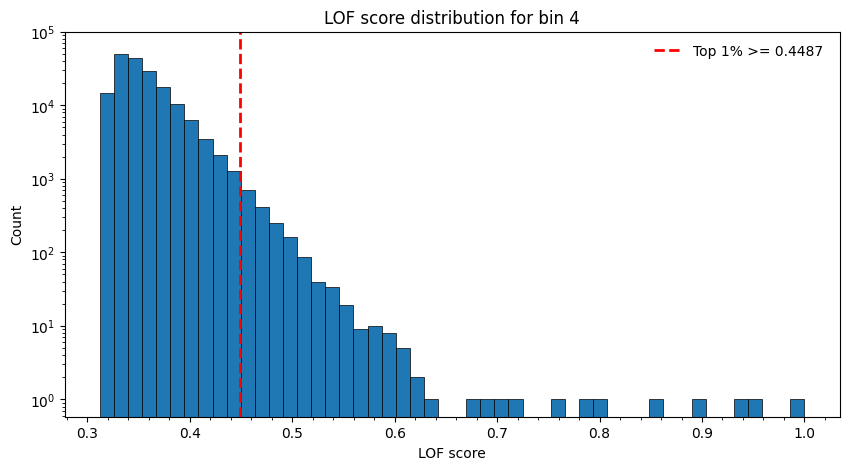

In [22]:
bin_id = 'bin_03'
fig, ax = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_02

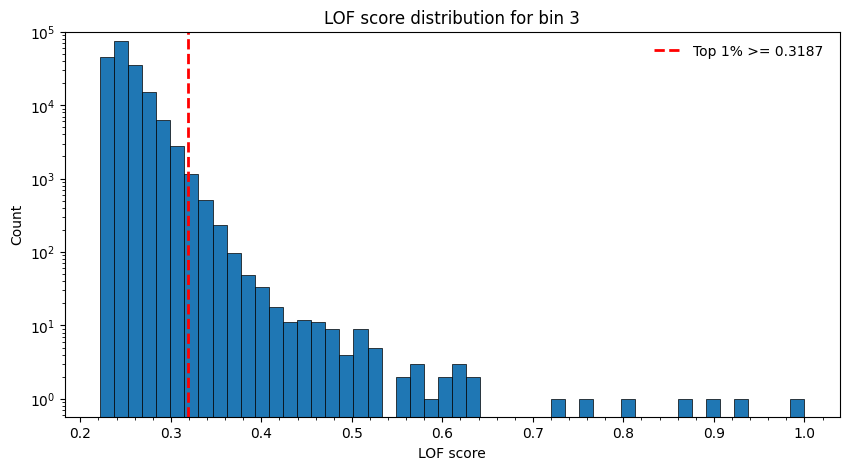

In [23]:
bin_id = 'bin_02'
fig, ax = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_01

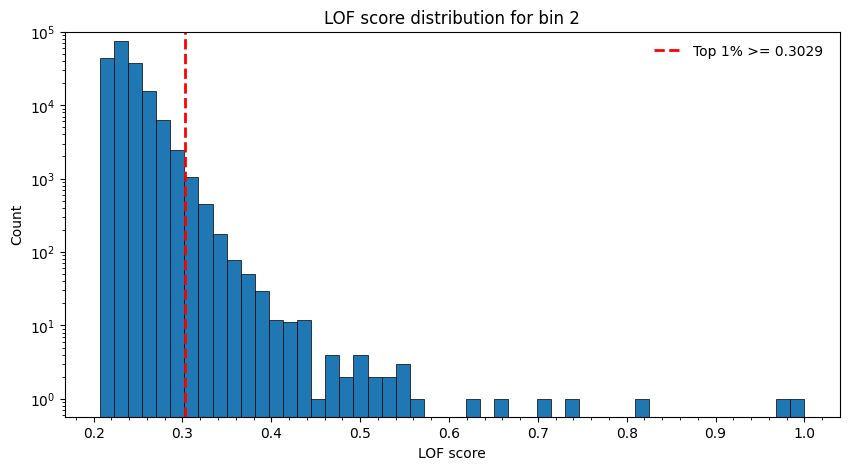

In [25]:
bin_id = 'bin_01'
fig, ax = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e5), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_00

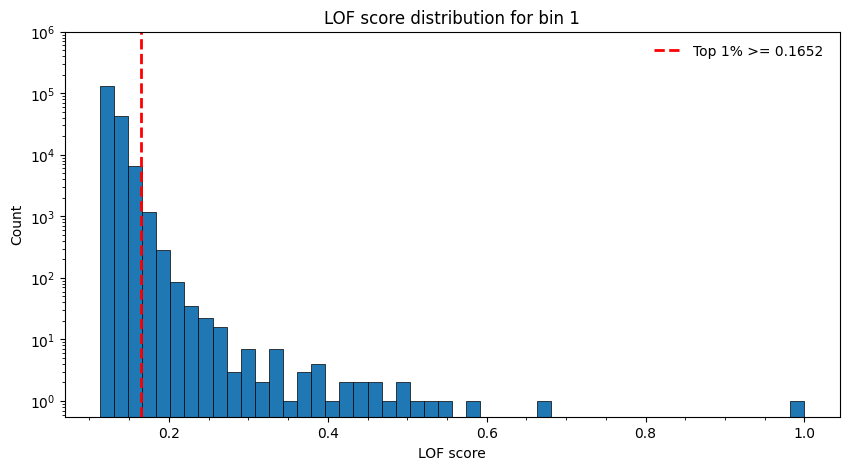

In [26]:
bin_id = 'bin_00'
fig, ax = lof_hist(bin_id, scores_df_dict, n_bins=50, y_lim=(None, 1e6), figsize=(10, 5))
metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)
os.makedirs(save_to, exist_ok=True)

fname = f"lof_hist_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

# Median spectra

In [32]:
specid_top_1_dict = {}

for bin_id in bins_ids:

    score_df = scores_df_dict[bin_id]

    top_k_specids = specids_from_lof_scores(score_df, quantile=0.99)
    specid_top_1_dict[bin_id] = top_k_specids

In [33]:
spec_idx_dict = {}

for bin_id, objids in specid_top_1_dict.items():

    spec_idx_list = []

    for objid in objids:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)

    spec_idx_dict[bin_id] = spec_idx_list

## bin_03

In [34]:
bin_id = 'bin_03'
spec_top_03 = spectra[spec_idx_dict[bin_id], :]
median_spec_top_03 = np.nanmedian(spec_top_03, axis=0)
mean_spec_top_03 = np.nanmean(spec_top_03, axis=0)

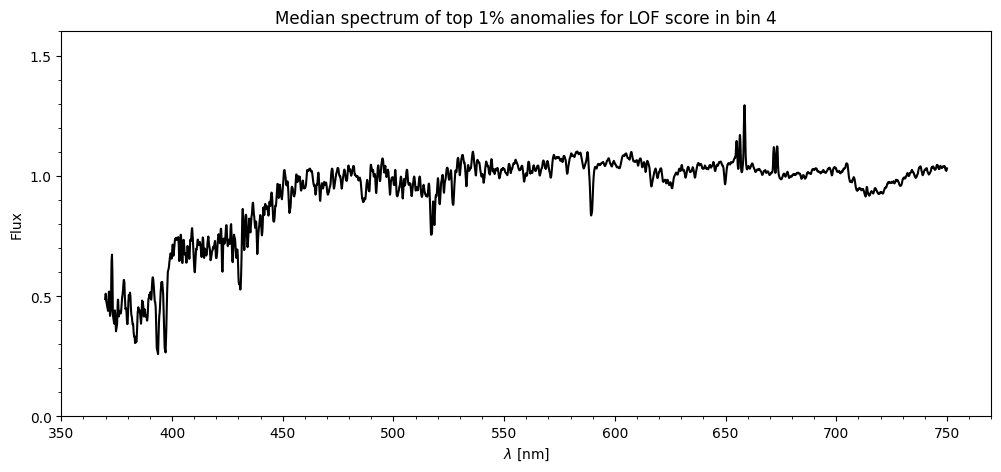

In [36]:
bin_id = 'bin_03'

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 5)
)

# ------------------------------------------------------
ax.plot(wave_nm, median_spec_top_03, color='black')
# wavelengt setup
ax.set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
ax.set_xticks(wave_ticks)

y_ticks = [0, 0.5, 1.0, 1.5]
ax.set_ylim(0, 1.6)
ax.set_yticks(y_ticks)
ax.minorticks_on()

ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")

title = f"Median spectrum of top 1% anomalies for LOF score in bin {int(bin_id.split('_')[-1])+1}"
ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

fname = f"median_spec_lof_top_1_pct_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_02

In [37]:
bin_id = 'bin_02'
spec_top_02 = spectra[spec_idx_dict[bin_id], :]
median_spec_top_02 = np.nanmedian(spec_top_02, axis=0)
mean_spec_top_02 = np.nanmean(spec_top_02, axis=0)

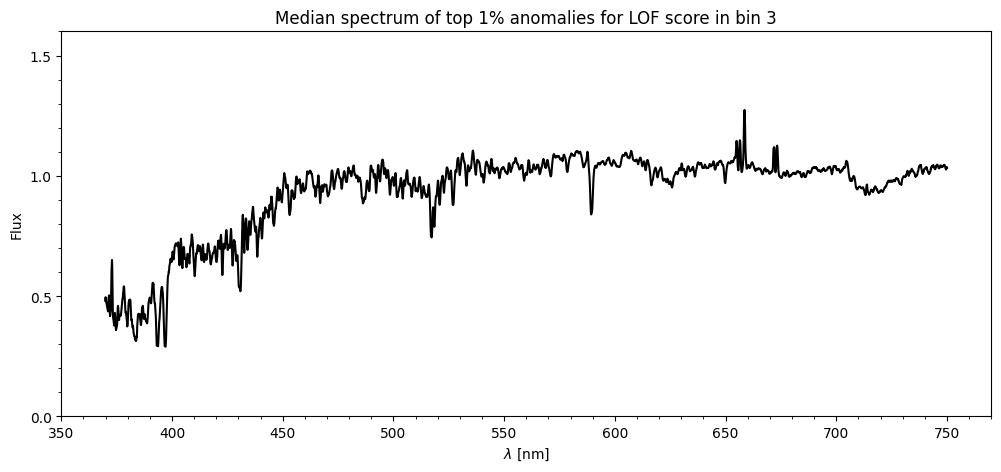

In [38]:
bin_id = 'bin_02'

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 5)
)

# ------------------------------------------------------
ax.plot(wave_nm, median_spec_top_02, color='black')
# wavelengt setup
ax.set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
ax.set_xticks(wave_ticks)

y_ticks = [0, 0.5, 1.0, 1.5]
ax.set_ylim(0, 1.6)
ax.set_yticks(y_ticks)
ax.minorticks_on()

ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")

title = f"Median spectrum of top 1% anomalies for LOF score in bin {int(bin_id.split('_')[-1])+1}"
ax.set_title(title, fontsize=12)
# save figure

save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

fname = f"median_spec_lof_top_1_pct_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_01

In [44]:
bin_id = 'bin_01'
spec_top_01 = spectra[spec_idx_dict[bin_id], :]
median_spec_top_01 = np.nanmedian(spec_top_01, axis=0)
mean_spec_top_01 = np.nanmean(spec_top_01, axis=0)

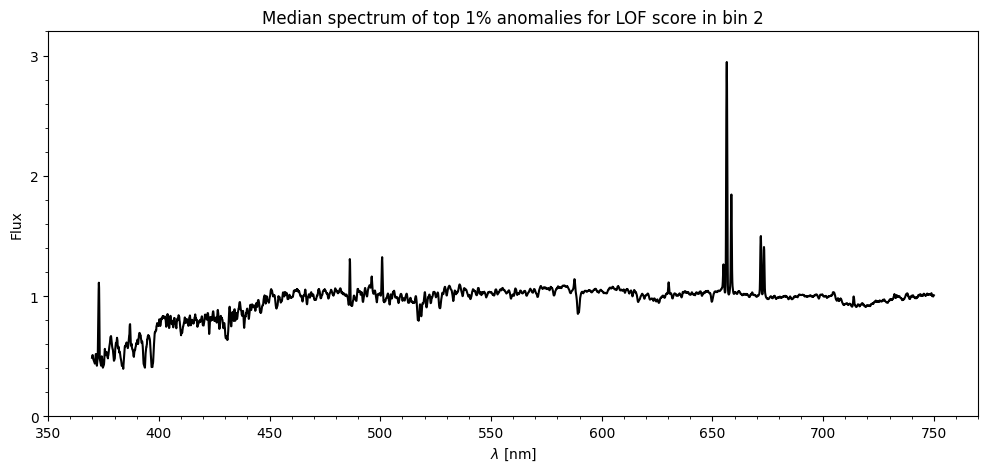

In [45]:
bin_id = 'bin_01'

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 5)
)

# ------------------------------------------------------
ax.plot(wave_nm, median_spec_top_01, color='black')
# wavelengt setup
ax.set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
ax.set_xticks(wave_ticks)

y_ticks = [0, 1, 2, 3]
ax.set_ylim(0, 3.2)
ax.set_yticks(y_ticks)
ax.minorticks_on()

ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")

title = f"Median spectrum of top 1% anomalies for LOF score in bin {int(bin_id.split('_')[-1])+1}"
ax.set_title(title, fontsize=12)
# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

fname = f"median_spec_lof_top_1_pct_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_00

In [46]:
bin_id = 'bin_00'
spec_top_00 = spectra[spec_idx_dict[bin_id], :]
median_spec_top_00 = np.nanmedian(spec_top_00, axis=0)
mean_spec_top_00 = np.nanmean(spec_top_00, axis=0)

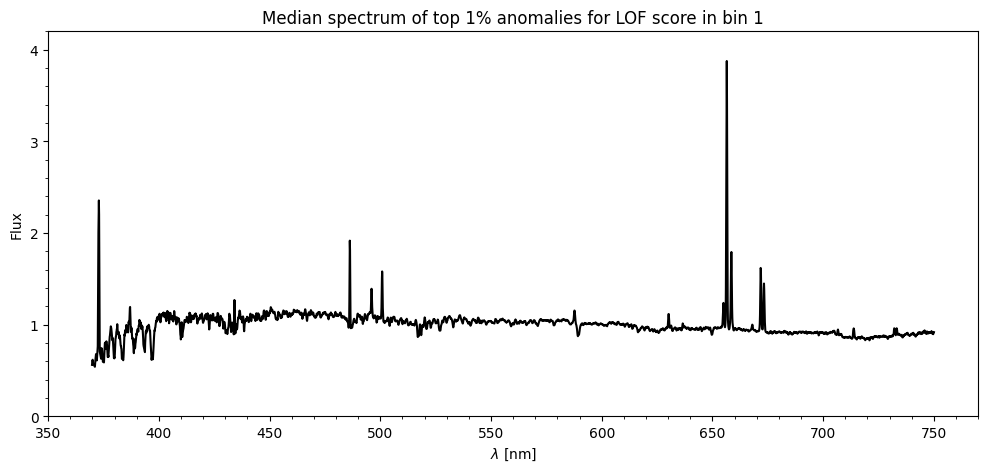

In [47]:
bin_id = 'bin_00'

fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 5)
)

# ------------------------------------------------------
ax.plot(wave_nm, median_spec_top_00, color='black')
# wavelengt setup
ax.set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
ax.set_xticks(wave_ticks)

y_ticks = [0, 1, 2, 3, 4]
ax.set_ylim(0, 4.2)
ax.set_yticks(y_ticks)
ax.minorticks_on()

ax.set_xlabel(r"$\lambda$ [nm]")
ax.set_ylabel("Flux")

title = f"Median spectrum of top 1% anomalies for LOF score in bin {int(bin_id.split('_')[-1])+1}"
ax.set_title(title, fontsize=12)
# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

fname = f"median_spec_lof_top_1_pct_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

# Plot anomalies

```python
bin_id = 'bin_03'
top_1_thresholds = scores_df_dict[bin_id]['lof'].quantile(0.99)
n_top = (scores_df_dict[bin_id]['lof'] >= top_1_thresholds).sum()
# n_top = 182
print(n_top)
# plt.ioff()

for bin_id in bins_ids:

    specids_top_1 = scores_df_dict[bin_id]['lof'].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top]

    ranks = np.zeros(n_top).astype(int)

    specs_top_1 = np.empty((n_top, wave.size))

    for i, objid in enumerate(specids_top_1):

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        specs_top_1[i, :] = spectra[spec_idx, :]

        ranks[i] = i

    # -----------------------------------------------------------

    save_to = f"{latent_dir}/{bin_id}/figs/"
    print(save_to)
    os.makedirs(save_to, exist_ok=True)

    anomaly_plot(
        wave_nm, specs=specs_top_1,
        objids=specids_top_1, ranks=ranks,
        save_to=save_to,
        figsize=(16, 6)
    )
```

# S/N vs LOF

## bin_03

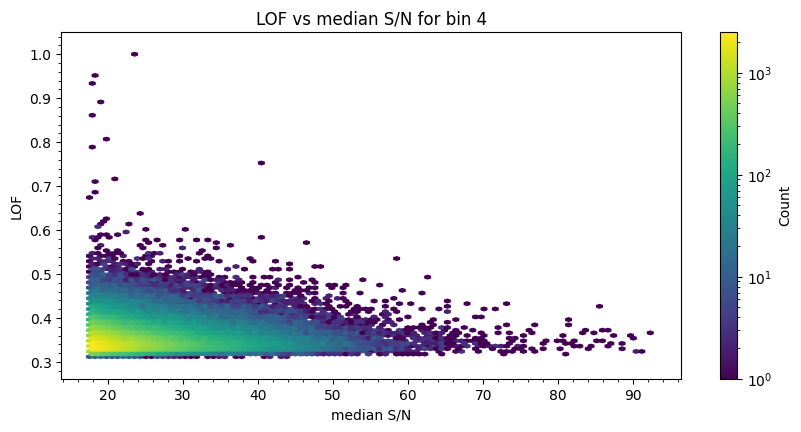

In [73]:
bin_id = 'bin_03'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'snMedian'
x_label='median S/N'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_snr_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

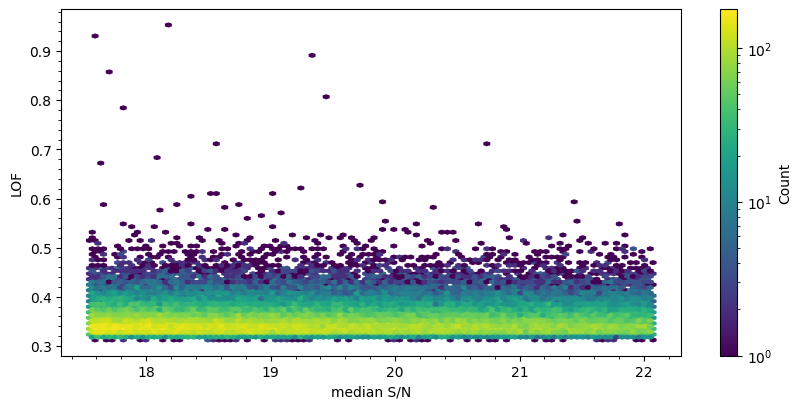

In [75]:
bin_id = 'bin_03'
df = scores_df_dict[bin_id].copy()
score = 'lof'
x_col = 'snMedian'
# ------------------------------------
snr_min = df['snMedian'].min()
snr_50 = df['snMedian'].quantile(0.5)
snr_mask = df['snMedian'] <= snr_50
snr_trim_df = df.loc[snr_mask].copy()

fig, axs = plot_hist_lof_z_snr(
    df=snr_trim_df,
    score=score,
    x_col=x_col,
    x_label='median S/N'
)

title = (
    f"LOF vs {x_label} (50% quantile) for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_snr_50q_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_02

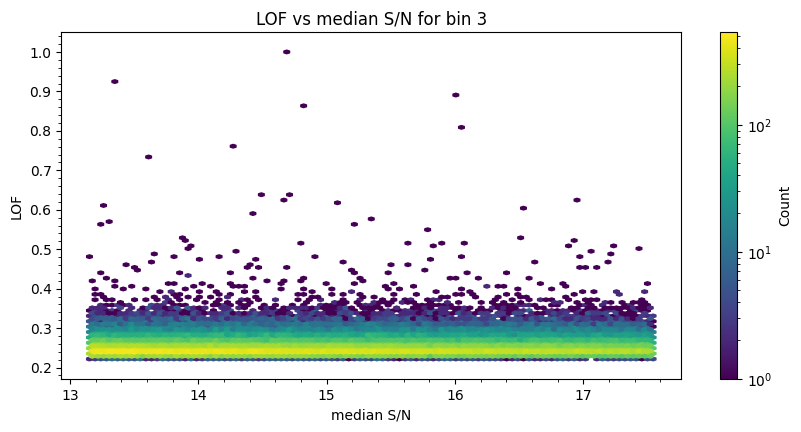

In [77]:
bin_id = 'bin_02'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'snMedian'
x_label='median S/N'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_snr_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_01

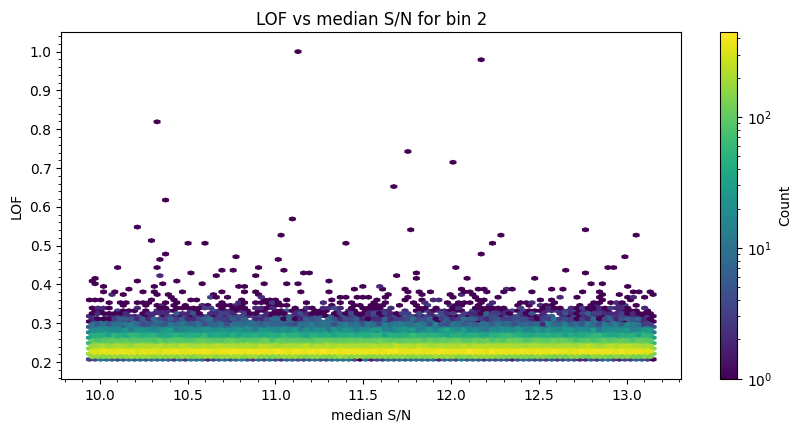

In [78]:
bin_id = 'bin_01'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'snMedian'
x_label='median S/N'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_snr_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_00

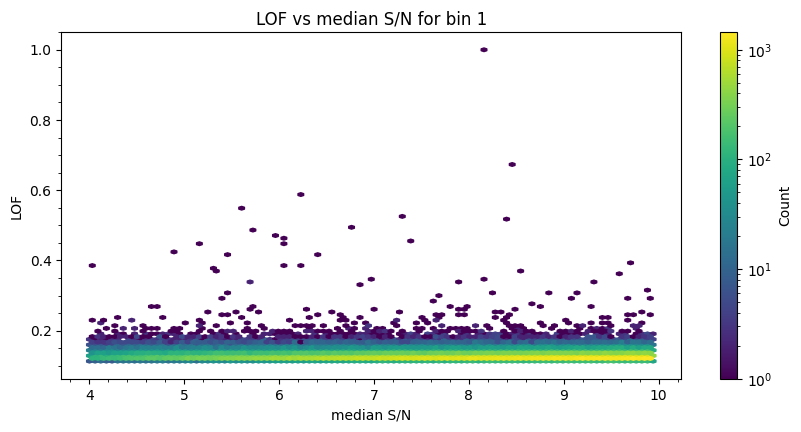

In [79]:
bin_id = 'bin_00'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'snMedian'
x_label='median S/N'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_snr_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

# z Vs LOF

## bin_03

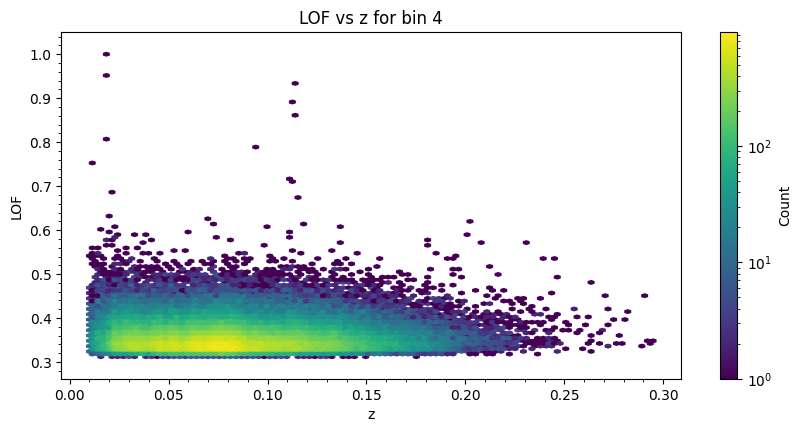

In [84]:
bin_id = 'bin_03'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'z'
x_label='z'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_z_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

### S/N trim

Text(0.5, 1.0, 'LOF vs z (50% quantile) for bin 4')

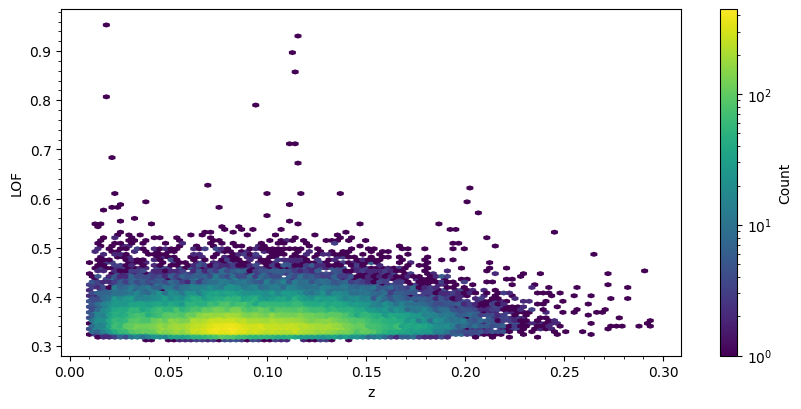

In [88]:
bin_id = 'bin_03'
df = scores_df_dict[bin_id].copy()
score = 'lof'
x_col = 'z'
x_label='z'
# ------------------------------------
snr_min = df['snMedian'].min()
snr_50 = df['snMedian'].quantile(0.5)
snr_mask = df['snMedian'] <= snr_50
snr_trim_df = df.loc[snr_mask].copy()

fig, axs = plot_hist_lof_z_snr(
    df=snr_trim_df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} (50% quantile) for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# # save figure
# save_to = os.path.join(
#     ch4_dir, bin_id, 'latent',
# )

# os.makedirs(save_to, exist_ok=True)

# metric = 'manhattan'
# n = 60
# model_tail_name = f'n{n}_{metric}'


# fname = f"lof_z_50q_{bin_id}_{model_tail_name}.pdf" 

# fig.savefig(
#     os.path.join(save_to, fname),
#     bbox_inches='tight'
# )

## bin_02

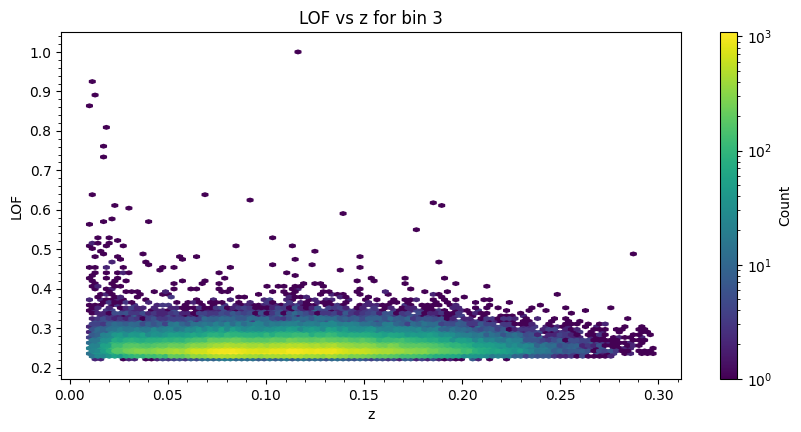

In [85]:
bin_id = 'bin_02'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'z'
x_label='z'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_z_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_01

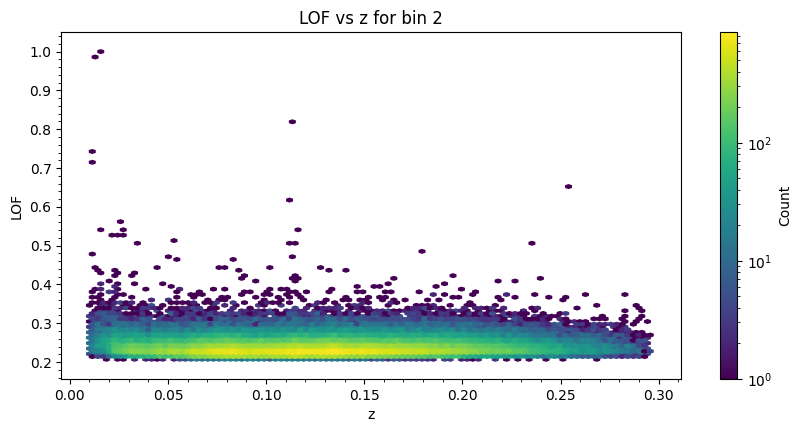

In [86]:
bin_id = 'bin_01'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'z'
x_label='z'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_z_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)

## bin_00

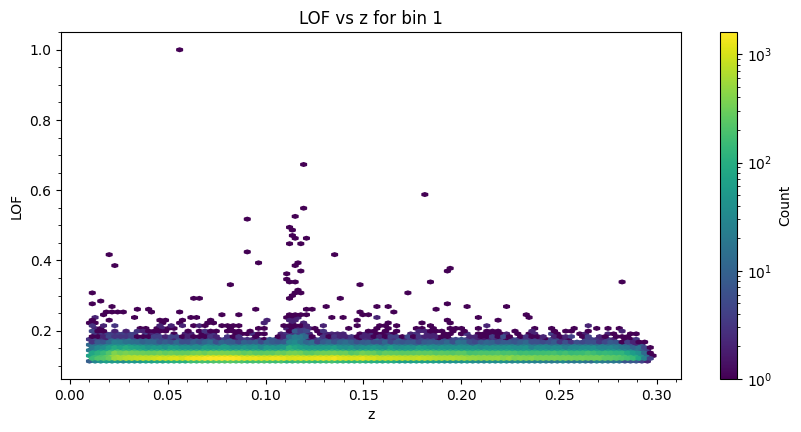

In [87]:
bin_id = 'bin_00'
df = scores_df_dict[bin_id]
score = 'lof'
x_col = 'z'
x_label='z'

fig, ax = plot_hist_lof_z_snr(
    df=df,
    score=score,
    x_col=x_col,
    x_label=x_label
)

title = (
    f"LOF vs {x_label} for bin "
    f"{int(bin_id.split('_')[-1])+1}"
)

y_lims = (df[score].min()-0.05, 1.05)
ax.set_ylim(y_lims)

ax.set_title(title, fontsize=12)

# save figure
save_to = os.path.join(
    ch4_dir, bin_id, 'latent',
)

os.makedirs(save_to, exist_ok=True)

metric = 'manhattan'
n = 60
model_tail_name = f'n{n}_{metric}'


fname = f"lof_z_{bin_id}_{model_tail_name}.pdf" 

fig.savefig(
    os.path.join(save_to, fname),
    bbox_inches='tight'
)